Dataset shape: (335, 8)
   0.49  0.29  0.48  0.50  0.56  0.24  0.35  cp
0  0.07  0.40  0.48   0.5  0.54  0.35  0.44  cp
1  0.56  0.40  0.48   0.5  0.49  0.37  0.46  cp
2  0.59  0.49  0.48   0.5  0.52  0.45  0.36  cp
3  0.23  0.32  0.48   0.5  0.55  0.25  0.35  cp
4  0.67  0.39  0.48   0.5  0.36  0.38  0.46  cp
Best K: 5
Best Silhouette Score: 0.40540757738652383

Cluster Counts:
Cluster
0     75
1      1
2    103
3      9
4    147
Name: count, dtype: int64


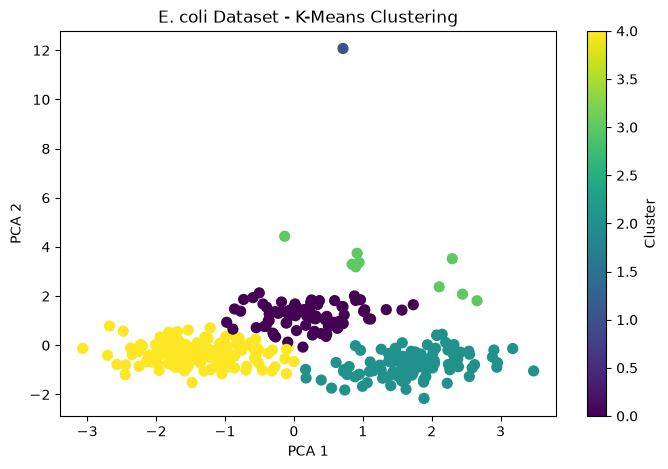


Results saved to ecoli_kmeans_results.csv


In [1]:
# E. COLI DATASET - K-MEANS CLUSTERING

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Load dataset
df = pd.read_csv("ecoli.csv")

print("Dataset shape:", df.shape)
print(df.head())

# 2. Select numerical columns
X = df.select_dtypes(include="number")

# 3. Fill missing values
X = pd.DataFrame(
    SimpleImputer(strategy="mean").fit_transform(X),
    columns=X.columns
)

# 4. Standardize data
X_scaled = StandardScaler().fit_transform(X)

# 5. Find best K using silhouette score
scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

best_k = range(2, 11)[scores.index(max(scores))]

print("Best K:", best_k)
print("Best Silhouette Score:", max(scores))

# 6. Final K-Means model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# 7. Show cluster counts
print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())

# 8. PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 9. Plot clusters
plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("E. coli Dataset - K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

# 10. Save results
df.to_csv("ecoli_kmeans_results.csv", index=False)

print("\nResults saved to ecoli_kmeans_results.csv")